In [1]:
import os


import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import math
import time
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
from transformers import MobileViTV2ForImageClassification 

import litert_torch
import torch
import torch.nn as nn
import torch.optim as optim
from ai_edge_litert.interpreter import Interpreter
from ai_edge_quantizer import quantizer, recipe
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
       torch.cuda.manual_seed(seed)
       torch.cuda.manual_seed_all(seed)
       torch.backends.cudnn.deterministic = False
       torch.backends.cudnn.benchmark = True

set_seed(SEED)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


In [2]:
!pwd

/home/jovyan/work/UFSC/butterflies_austria/butterflies_austria_edge_vision/pytorch_mobilevit_xxs/MobileVITv2/butterflies_austria_MobileVITv2_baseline_v0


# Setup

In [3]:
PATH = "/home/jovyan/work/UFSC/butterflies_austria/Dataset_train_test_split/butterflies-austria"

EPOCHS = 40
PATIENCE_ES = 8
BATCH_SIZE = 64

LR = 1e-3

GRAD_CLIP = 1.0

IMG_SIZE = 256
RESIZE_SIZE = 288
MODEL_SAVE_PATH = "best_mobilevit_xx_small.pt"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")

Device: cuda


# Dataset

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize(RESIZE_SIZE),
    transforms.RandomCrop(IMG_SIZE),
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.RandomHorizontalFlip(p=0.1),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Lambda(lambda image: image[[2, 1, 0]])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(RESIZE_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.Lambda(lambda image: image.convert("RGB")),
    transforms.ToTensor(),
    transforms.Lambda(lambda image: image[[2, 1, 0]])
])

In [5]:
train_dir = os.path.join(PATH, "train")
val_dir = os.path.join(PATH, "val")
test_dir = os.path.join(PATH, "test")

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

if val_dataset.class_to_idx != class_to_idx:
    raise ValueError("Training and validation classes are not aligned")

if test_dataset.class_to_idx != class_to_idx:
    raise ValueError("Training and test classes are not aligned")

pin_memory = DEVICE.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=pin_memory,
    persistent_workers=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=pin_memory,
    persistent_workers=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=pin_memory,
    persistent_workers=True,
)

print(f"Classes: {len(class_names)}")
print(
    f"Train: {len(train_dataset)} | "
    f"Val: {len(val_dataset)} | "
    f"Test: {len(test_dataset)}"
)

Classes: 20
Train: 5183 | Val: 648 | Test: 648


Training distribution:
  Aglais_Urticae                : 215
  Anthocharis_Cardamines        : 361
  Apatura_Iris                  : 279
  Argynnis_Paphia               : 316
  Colias_Myrmidone              : 227
  Gonepteryx_Rhamni             : 186
  Inachis_Io                    : 218
  Iphiclides_Podalirius         : 238
  Lycaena_Virgaureae            : 137
  Lycaenidae                    : 332
  Maniola_Jurtina               : 326
  Melanargia_Galathea           : 328
  Nymphalis_Antiopa             : 128
  Papilio_Machaon               : 194
  Parnassius_Apollo             : 247
  Pieris_Rapae                  : 294
  Polygonia_C-album             : 317
  Vanessa_Atalanta              : 379
  Vanessa_Cardui                : 266
  Zerynthia_Polyxena            : 195


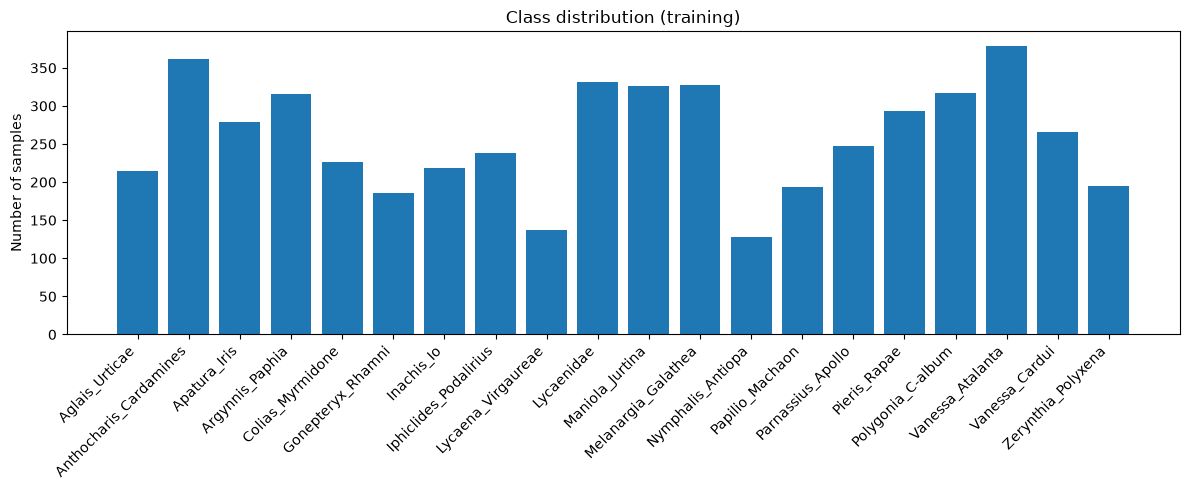

Class weights: [1.0633659362792969, 0.8206319212913513, 0.9334689974784851, 0.8771188855171204, 1.0348777770996094, 1.1432613134384155, 1.0560239553451538, 1.0106796026229858, 1.3321149349212646, 0.8557224869728088, 0.8635613322257996, 0.8609245419502258, 1.3781516551971436, 1.1194407939910889, 0.9920955896377563, 0.9093442559242249, 0.8757343292236328, 0.800907552242279, 0.9560072422027588, 1.116566777229309]


In [6]:
train_targets = np.asarray(train_dataset.targets)
train_counts = np.bincount(train_targets, minlength=len(class_names))

print("Training distribution:")
for name, count in zip(class_names, train_counts):
    print(f"  {name:30s}: {count}")

plt.figure(figsize=(12, 5))
plt.bar(class_names, train_counts)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of samples")
plt.title("Class distribution (training)")
plt.tight_layout()
plt.show()

class_weights = len(train_targets) / (
    len(class_names) * train_counts
)

class_weights = np.sqrt(class_weights)
class_weights = class_weights / class_weights.mean()

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE,
)
print(f"Class weights: {class_weights.tolist()}")

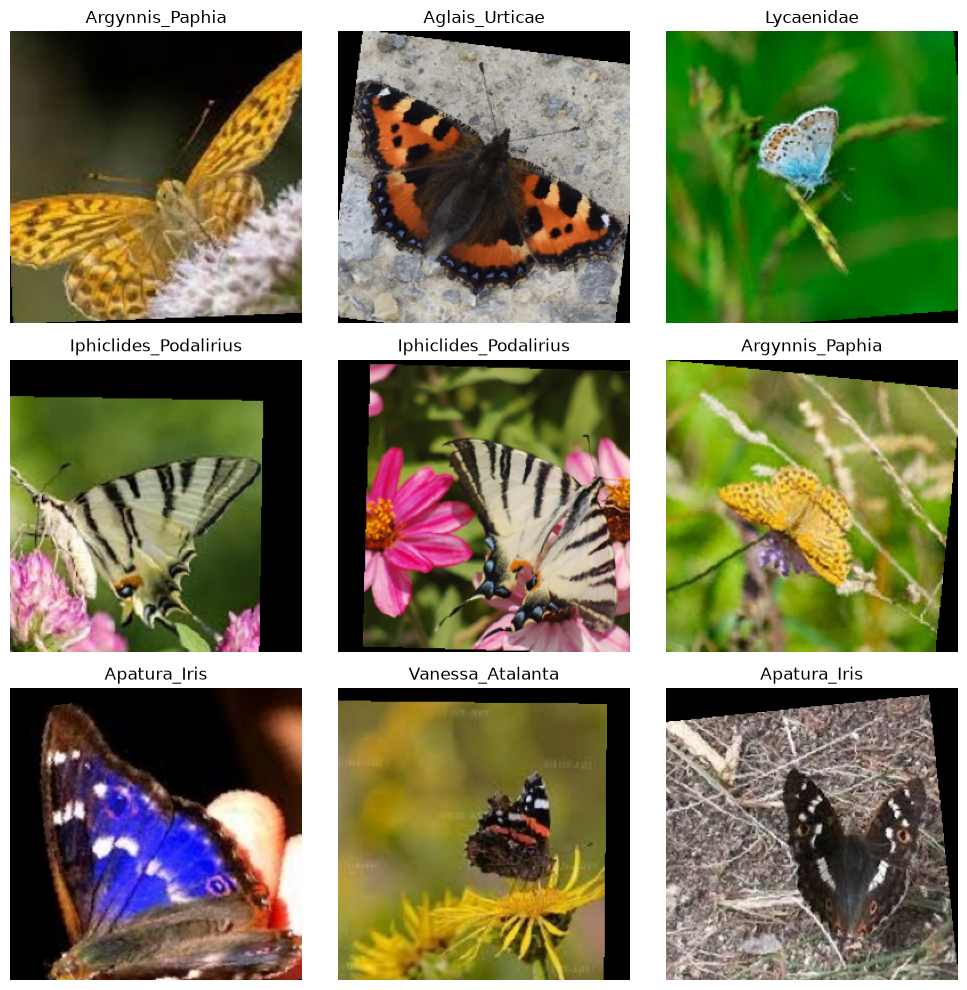

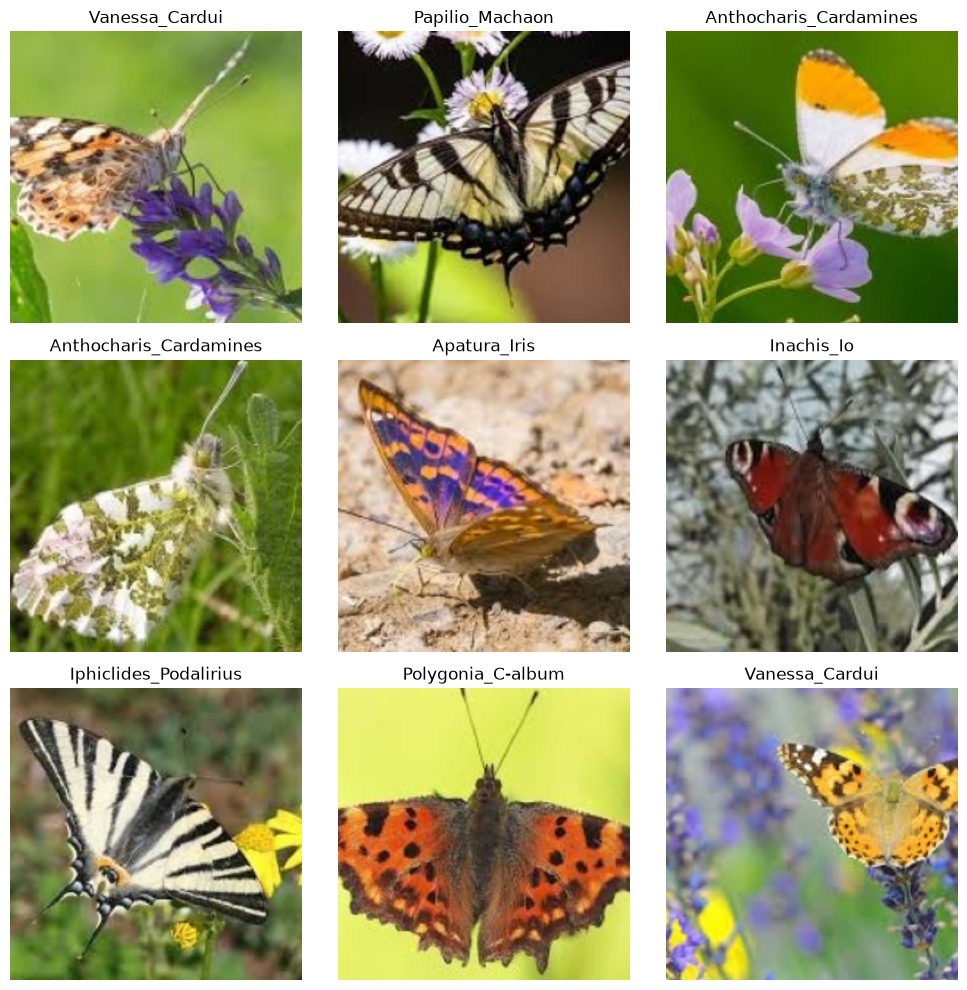

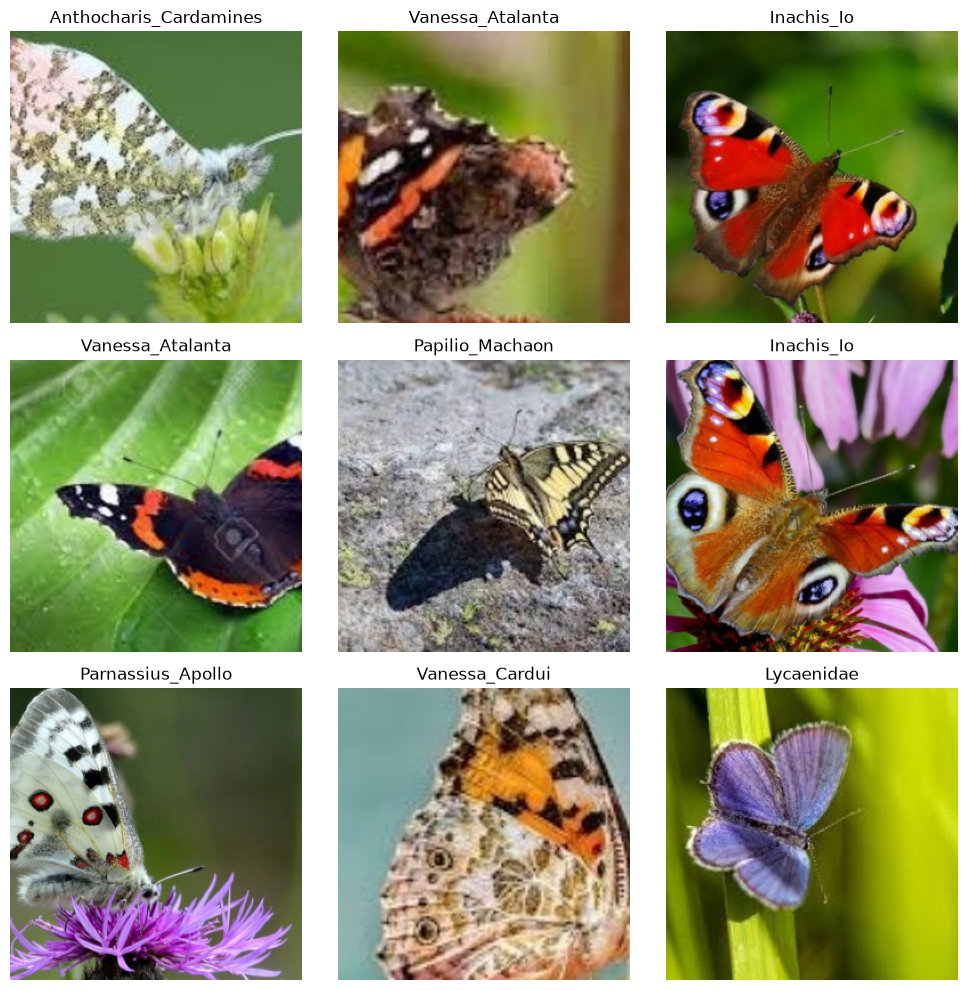

In [7]:
def plot_samples(dataset, class_names, num_samples=9):
    cols = 3
    rows = math.ceil(num_samples / cols)
    plt.figure(figsize=(10, 10))

    indices = random.sample(range(len(dataset)), num_samples)

    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        img_np = img_tensor[[2, 1, 0]].permute(1, 2, 0).numpy()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_np)
        plt.title(class_names[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_samples(train_dataset, class_names)
plot_samples(test_dataset, class_names)
plot_samples(val_dataset, class_names)

# Model

In [8]:
MODEL_NAME = "apple/mobilevitv2-1.0-imagenet1k-256"

hf_model = MobileViTV2ForImageClassification.from_pretrained(          
         MODEL_NAME,                                                        
         num_labels=len(class_names),                                       
         id2label={i: name for i, name in enumerate(class_names)},          
         label2id={name: i for i, name in enumerate(class_names)},          
         classifier_dropout_prob=0.3,                                       
         ignore_mismatched_sizes=True,                                      
     )

class MobileViTClassifier(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(pixel_values=x, return_dict=False)[0]

model = MobileViTClassifier(hf_model).to(DEVICE)

config.json:   0%|          | 0.00/69.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=20` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 19.8MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

[transformers] MobileViTV2ForImageClassification LOAD REPORT from: apple/mobilevitv2-1.0-imagenet1k-256
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 512]) vs model:torch.Size([20, 512])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([20])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [9]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 4,399,101


model.safetensors: reconstructing file:   0%|          |  0.00B / 19.7MB            

model.safetensors: downloading bytes:           |  0.00B            

# Train

In [10]:
# Fine-tuning: classifier novo (aleatorio) precisa de LR maior que o backbone pre-treinado
backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
head_params     = [p for n, p in model.named_parameters() if 'classifier' in n]

optimizer = optim.AdamW(
    [
        {"params": backbone_params, "lr": LR / 10},
        {"params": head_params, "lr": LR},
    ],
    weight_decay=1e-4,
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05,
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=[LR / 10, LR],
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS,
    div_factor=100,
    final_div_factor=100,
)

# Treinamento
best_acc = 0.0
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [11]:
print("Starting training...")

for epoch in tqdm(range(EPOCHS), desc="Training Progress"):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    model.eval()
    val_loss_running = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss_running += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss_running / len(val_dataset)
    val_acc = correct_val / total_val
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]

    tqdm.write(
        f"[{epoch+1:03d}/{EPOCHS}] "
        f"train_loss={epoch_loss:.4f} train_acc={epoch_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"lr={current_lr:.2e}"
    )

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE_ES:
            tqdm.write(f"Early stopping triggered at epoch {epoch + 1}.")
            break

model.load_state_dict(best_model_wts)
print(f"Best validation accuracy: {best_acc:.4f}")

Starting training...


Training Progress:   0%|          | 0/40 [00:00<?, ?it/s]

[001/40] train_loss=3.0032 train_acc=0.0546 | val_loss=2.9894 val_acc=0.0664 | lr=2.69e-06
[002/40] train_loss=2.9682 train_acc=0.1001 | val_loss=2.9282 val_acc=0.1775 | lr=7.65e-06
[003/40] train_loss=2.8592 train_acc=0.3270 | val_loss=2.7562 val_acc=0.5324 | lr=1.55e-05
[004/40] train_loss=2.5635 train_acc=0.6583 | val_loss=2.2722 val_acc=0.7793 | lr=2.58e-05
[005/40] train_loss=1.8814 train_acc=0.7887 | val_loss=1.3403 val_acc=0.8796 | lr=3.78e-05
[006/40] train_loss=1.0774 train_acc=0.8717 | val_loss=0.7161 val_acc=0.9475 | lr=5.06e-05
[007/40] train_loss=0.6939 train_acc=0.9209 | val_loss=0.5328 val_acc=0.9660 | lr=6.34e-05
[008/40] train_loss=0.5795 train_acc=0.9412 | val_loss=0.4871 val_acc=0.9691 | lr=7.53e-05
[009/40] train_loss=0.5357 train_acc=0.9508 | val_loss=0.4611 val_acc=0.9784 | lr=8.56e-05
[010/40] train_loss=0.5037 train_acc=0.9601 | val_loss=0.4481 val_acc=0.9784 | lr=9.34e-05
[011/40] train_loss=0.4783 train_acc=0.9649 | val_loss=0.4351 val_acc=0.9815 | lr=9.84e-05

# Test

Final test accuracy: 0.9769


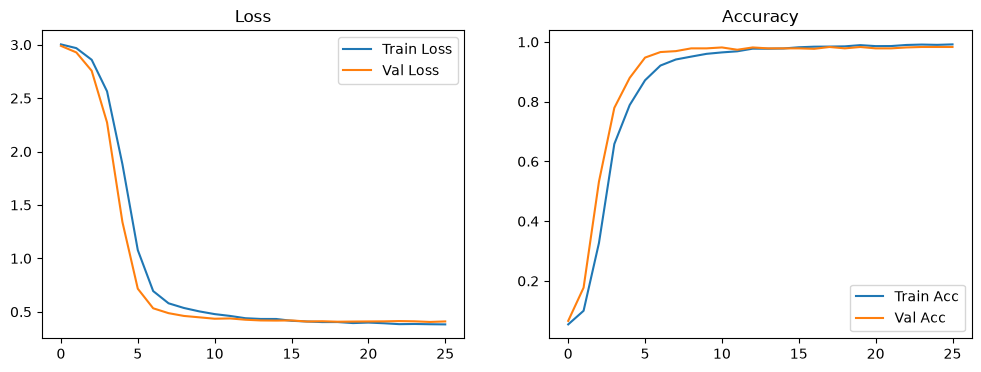

In [12]:
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f"Final test accuracy: {test_correct / test_total:.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title("Accuracy")
plt.show()

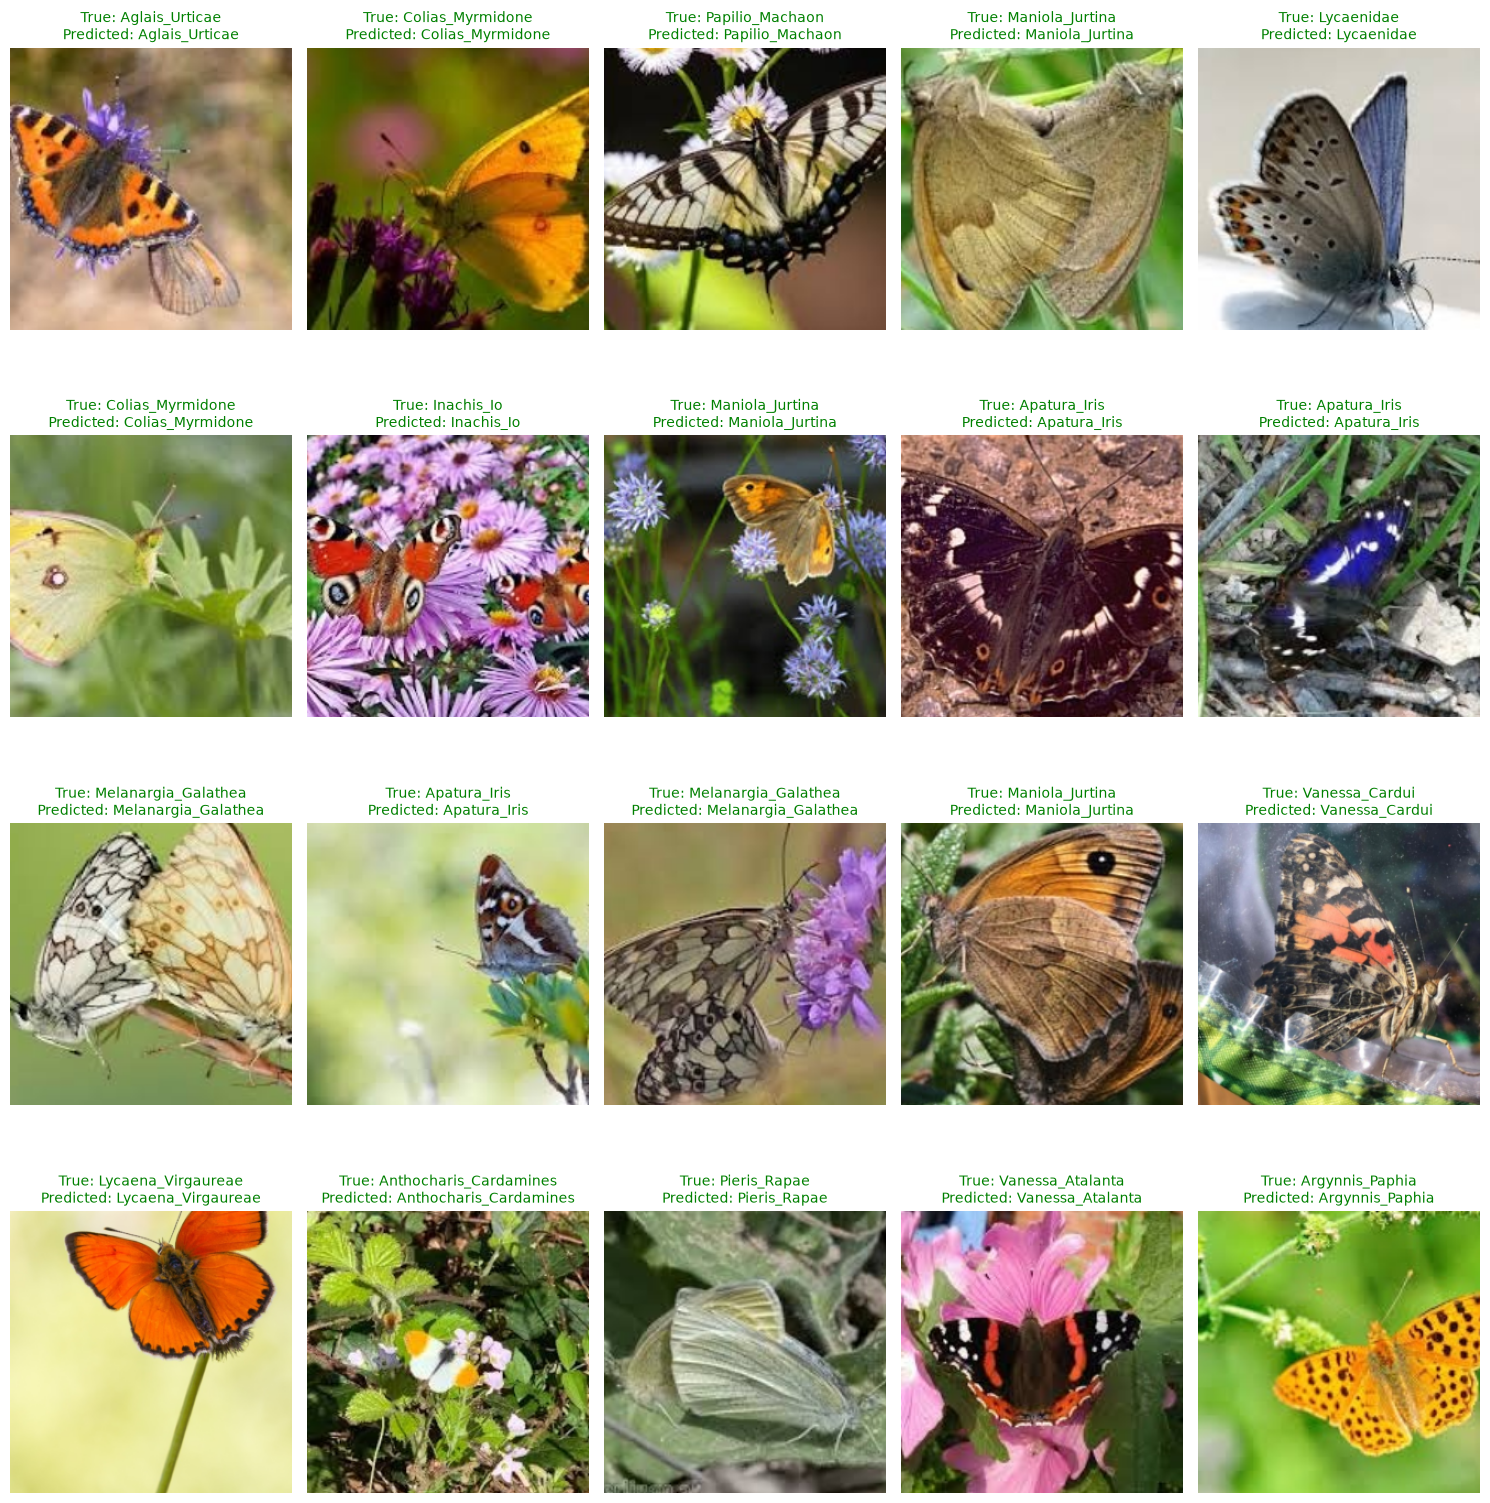

In [13]:
def predict_and_plot(model, dataset, classes, num_samples=10):
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    cols = 5
    rows = math.ceil(num_samples / cols)

    plt.figure(figsize=(15, 4 * rows))

    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        img_input = img_tensor.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(img_input)
            pred = output.argmax(dim=1).item()

        img_np = img_tensor[[2, 1, 0]].permute(1, 2, 0).numpy()

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_np)

        color = "green" if pred == label else "red"
        plt.title(f"True: {classes[label]}\nPredicted: {classes[pred]}", color=color, fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

predict_and_plot(model, test_dataset, class_names, num_samples=20)

                        precision    recall  f1-score   support

        Aglais_Urticae     0.9286    0.9630    0.9455        27
Anthocharis_Cardamines     0.9167    0.9778    0.9462        45
          Apatura_Iris     1.0000    1.0000    1.0000        35
       Argynnis_Paphia     1.0000    1.0000    1.0000        40
      Colias_Myrmidone     1.0000    0.9643    0.9818        28
     Gonepteryx_Rhamni     0.9200    1.0000    0.9583        23
            Inachis_Io     1.0000    1.0000    1.0000        28
 Iphiclides_Podalirius     1.0000    1.0000    1.0000        29
    Lycaena_Virgaureae     0.9412    0.9412    0.9412        17
            Lycaenidae     1.0000    1.0000    1.0000        41
       Maniola_Jurtina     1.0000    0.9756    0.9877        41
   Melanargia_Galathea     1.0000    1.0000    1.0000        41
     Nymphalis_Antiopa     0.9375    0.9375    0.9375        16
       Papilio_Machaon     1.0000    1.0000    1.0000        24
     Parnassius_Apollo     0.9677    0.

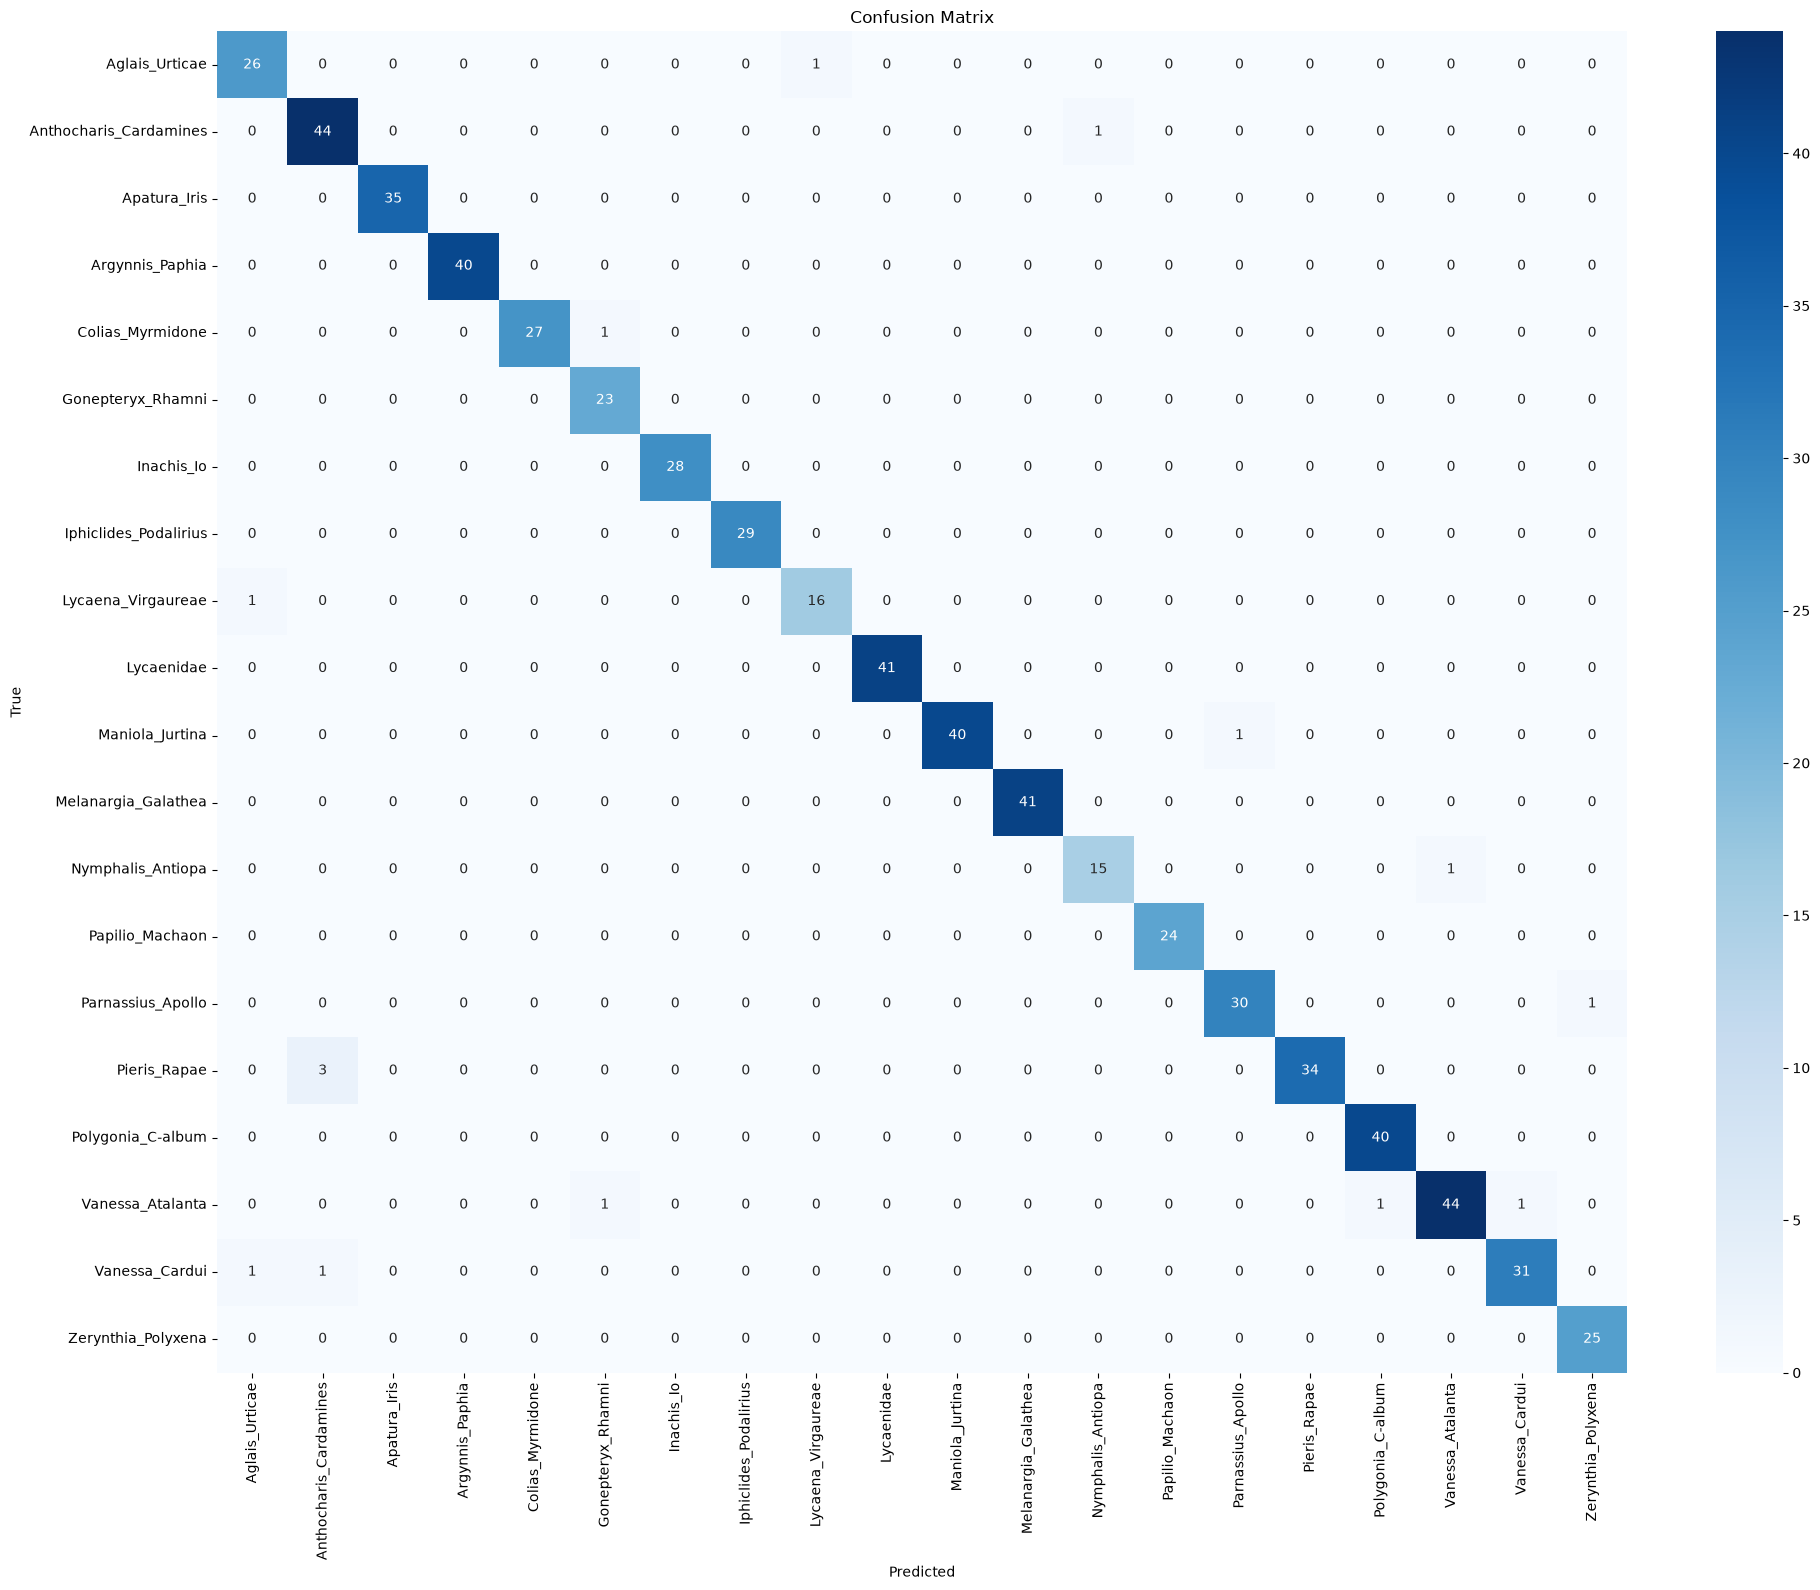

In [14]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

labels = range(len(class_names))

print(
    classification_report(
        all_labels,
        all_preds,
        labels=labels,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(all_labels, all_preds, labels=labels)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Export Edge AI

In [15]:
EXPORT_DIR = Path("tflite_models")
EXPORT_DIR.mkdir(exist_ok=True)

NUM_CALIB_SAMPLES = 100

FP32_PATH = EXPORT_DIR / "model_fp32.tflite"
INT8A16_PATH = EXPORT_DIR / "model_int8a16.tflite"
INT8_PATH = EXPORT_DIR / "model_int8.tflite"

In [16]:
calibration_dataset = datasets.ImageFolder(train_dir, transform=val_test_transforms)

In [17]:
export_model = copy.deepcopy(model).cpu().eval()

sample_image = test_dataset[0][0]
sample_inputs = (sample_image.unsqueeze(0).cpu(),)

print(sample_inputs[0].shape)

torch.Size([1, 3, 256, 256])


In [18]:
edge_model = litert_torch.convert(export_model, sample_inputs)
edge_model.export(str(FP32_PATH))

print(f"FP32: {FP32_PATH.stat().st_size / 1024 / 1024:.2f} MB")

(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/opt/conda/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:02) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions (+00:01)

...

(00:15) [ DONE] LiteRT-Torch Convert > Merge MLIR Modules (+00:00)

(00:15) [START] LiteRT-Torch Convert > Run LiteRT Converter Passes

(00:16) [ FAIL] LiteRT-Torch Convert > Run LiteRT Converter Passes

(00:16) [ FAIL] LiteRT-Torch Convert

ValueError: Failed to run converter passes: /opt/conda/lib/python3.11/site-packages/transformers/models/mobilevitv2/modeling_mobilevitv2.py:253:0: error: 'tfl.mul' op operands don't have broadcast-compatible shapes


In [ ]:
def create_calibration_data(model_path, dataset, num_samples=200, seed=42):
    interpreter = Interpreter(model_path=str(model_path))
    signatures = interpreter.get_signature_list()

    if len(signatures) != 1:
        raise ValueError(f"Expected one signature, found: {list(signatures)}")

    signature_name, signature = next(iter(signatures.items()))
    input_names = signature["inputs"]

    if len(input_names) != 1:
        raise ValueError(f"Expected one input, found: {input_names}")

    input_name = input_names[0]

    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=generator)[:min(num_samples, len(dataset))].tolist()

    samples = []

    for index in indices:
        image = dataset[index][0]
        samples.append({input_name: image.unsqueeze(0).cpu().numpy().astype(np.float32)})

    return {signature_name: samples}

calibration_data = create_calibration_data(FP32_PATH, calibration_dataset, NUM_CALIB_SAMPLES)

In [ ]:
def quantize_static(fp32_path, output_path, calibration_data, quantization_recipe):
    qt = quantizer.Quantizer(str(fp32_path))
    qt.load_quantization_recipe(quantization_recipe())
    calibration_result = qt.calibrate(calibration_data)
    result = qt.quantize(calibration_result)
    result.export_model(str(output_path), overwrite=True)

    print(f"{output_path.name}: {output_path.stat().st_size / 1024 / 1024:.2f} MB")

In [ ]:
quantize_static(FP32_PATH, INT8A16_PATH, calibration_data, recipe.static_wi8_ai16)

In [ ]:
quantize_static(FP32_PATH, INT8_PATH, calibration_data, recipe.static_wi8_ai8)

In [ ]:
def inspect_tflite(model_path):
    interpreter = Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()

    input_info = interpreter.get_input_details()[0]
    output_info = interpreter.get_output_details()[0]

    print(model_path.name)
    print(f"Input:  {input_info['shape']} {input_info['dtype']}")
    print(f"Output: {output_info['shape']} {output_info['dtype']}")
    print(f"Size:   {model_path.stat().st_size / 1024 / 1024:.2f} MB")

In [ ]:
inspect_tflite(FP32_PATH)
inspect_tflite(INT8A16_PATH)
inspect_tflite(INT8_PATH)

In [ ]:
def evaluate_tflite(model_path, data_loader, class_names):
    interpreter = Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_index = input_details["index"]
    output_index = output_details["index"]
    input_dtype = input_details["dtype"]
    output_dtype = output_details["dtype"]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    all_labels = []
    all_predictions = []

    for images, labels in data_loader:
        images = images.cpu().numpy()

        for image, label in zip(images, labels.numpy()):
            x = np.expand_dims(image, axis=0)

            if np.issubdtype(input_dtype, np.integer):
                if input_scale == 0:
                    raise ValueError(f"Invalid quantization scale in {model_path}")
                x = np.round(x / input_scale + input_zero_point)
                x = np.clip(x, np.iinfo(input_dtype).min, np.iinfo(input_dtype).max).astype(input_dtype)
            else:
                x = x.astype(input_dtype)

            interpreter.set_tensor(input_index, x)
            interpreter.invoke()

            output = interpreter.get_tensor(output_index)

            if np.issubdtype(output_dtype, np.integer) and output_scale > 0:
                output = (output.astype(np.float32) - output_zero_point) * output_scale

            prediction = int(np.argmax(output, axis=1)[0])

            all_labels.append(int(label))
            all_predictions.append(prediction)

    accuracy = accuracy_score(all_labels, all_predictions)

    print(f"\n{model_path.name}")
    print(f"Accuracy: {accuracy:.4f}\n")
    print(classification_report(all_labels, all_predictions, target_names=class_names, digits=4, zero_division=0))

    return accuracy, all_labels, all_predictions

In [ ]:
fp32_results = evaluate_tflite(FP32_PATH, test_loader, class_names)

In [ ]:
int8_results = evaluate_tflite(INT8_PATH, test_loader, class_names)

In [ ]:
int8a16_results = evaluate_tflite(INT8A16_PATH, test_loader, class_names)

In [ ]:
def print_tflite_io_types(model_path):
    interpreter = Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    print(f"\n{model_path.name}")
    print(f"inference_input_type:  {input_details['dtype']}")
    print(f"inference_output_type: {output_details['dtype']}")
    print(f"input quantization:     {input_details['quantization']}")
    print(f"output quantization:    {output_details['quantization']}")

print_tflite_io_types(FP32_PATH)
print_tflite_io_types(INT8A16_PATH)
print_tflite_io_types(INT8_PATH)